<a href="https://colab.research.google.com/github/Olacherish/DataScienceClass/blob/main/MY_RE_CAPSTONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPSTONE PROJECT: Transfer Learning with PyTorch
## CNN Transfer Learning — Image Classification on the Oxford-IIIT Pet Dataset (ResNet50)


**Pipeline:**
1. Data preprocessing & augmentation
2. Transfer learning using pretrained ResNet50
3. Train frozen model (feature extraction)
4. Fine-tune model (unfreeze + train with low LR)
5. Evaluate and compare accuracies (frozen vs fine-tuned)



## Please Note:
Run this notebook in an environment with internet access (e.g. Google Colab or a local machine) —
> `torchvision.datasets.OxfordIIITPet` downloads the dataset automatically the first time it runs (~800MB).
> A GPU is strongly recommended (Colab: Runtime → Change runtime type → GPU).


##0. Setup & Imports

In [ ]:
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms, models
from torchvision.datasets import OxfordIIITPet

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch:", torch.__version__, "| Torchvision:", torchvision.__version__)


Using device: cuda
Torch: 2.11.0+cu128 | Torchvision: 0.26.0+cu128


## 1. Data Preprocessing & Augmentation

The Oxford-IIIT Pet dataset has 37 breed classes (cats & dogs). We:
- Resize/crop images to 224×224 (ResNet50's expected input size)
- Apply data augmentation (random flips, rotation, color jitter) **only on the training set**
- Normalize using ImageNet mean/std, since ResNet50 was pretrained on ImageNet


In [ ]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [ ]:
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# torchvision's OxfordIIITPet ships with its own 'trainval' / 'test' splits.
# We use 'trainval' (with augmentation) for training/validation, and the official 'test' split
# (no augmentation) for final held-out evaluation.
full_train_raw = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category",
                                download=True, transform=train_transform)
test_dataset   = OxfordIIITPet(root=DATA_DIR, split="test", target_types="category",
                                download=True, transform=eval_transform)

CLASS_NAMES = full_train_raw.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Trainval size: {len(full_train_raw)} | Test size: {len(test_dataset)}")


100%|██████████| 792M/792M [00:37<00:00, 21.0MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.36MB/s]


Number of classes: 37
Trainval size: 3680 | Test size: 3669


In [ ]:
# Split trainval -> train / validation (85/15), keeping eval_transform for the validation subset.
val_fraction = 0.15
val_size = int(len(full_train_raw) * val_fraction)
train_size = len(full_train_raw) - val_size

# Build an eval-transformed copy of the same underlying data for validation
full_train_eval = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category",
                                 download=False, transform=eval_transform)

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(range(len(full_train_raw)), [train_size, val_size], generator=generator)

train_dataset = torch.utils.data.Subset(full_train_raw, train_indices.indices)
val_dataset   = torch.utils.data.Subset(full_train_eval, val_indices.indices)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}


Train: 3128 | Val: 552 | Test: 3669


### Visualize a batch of augmented training images

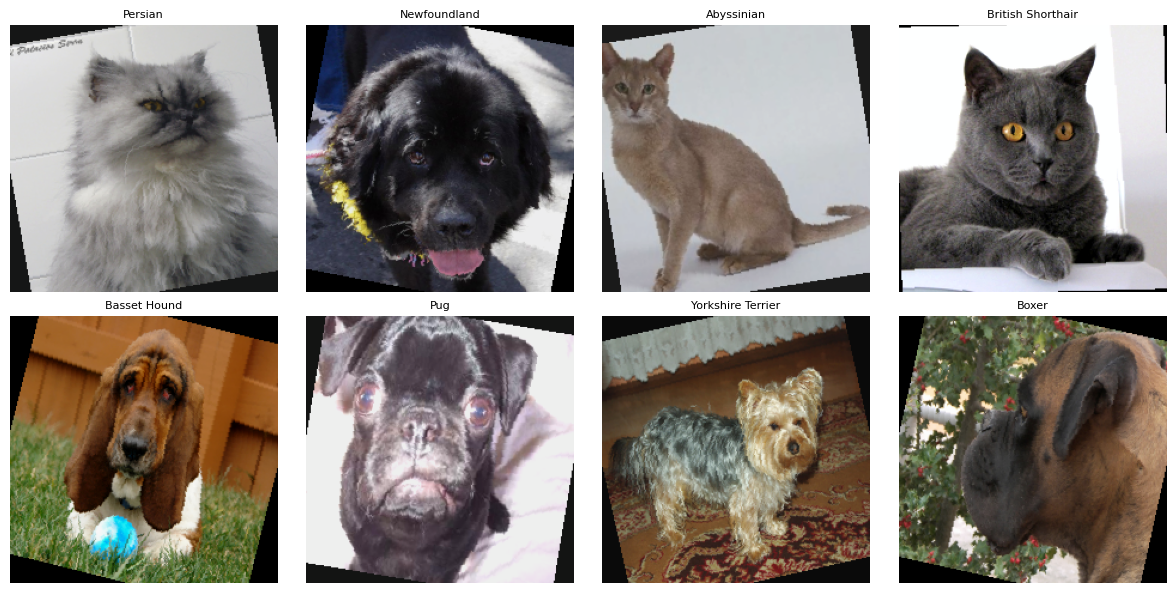

In [ ]:
def imshow(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title, fontsize=8)
    plt.axis("off")

inputs, classes = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i + 1)
    imshow(inputs[i], title=CLASS_NAMES[classes[i]])
plt.tight_layout()
plt.show()


## 2. Transfer Learning Setup — Pretrained ResNet50

We load ResNet50 pretrained on ImageNet and replace its final fully-connected layer
with a new head sized for our 37 pet breed classes.


In [ ]:
def build_resnet50(num_classes, pretrained=True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

criterion = nn.CrossEntropyLoss()


## 3. Generic Training / Evaluation Loop

In [ ]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler,
                 num_epochs=10, device=device):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    model = model.to(device)

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train" and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase:5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, dataloader, device=device):
    model.eval()
    model = model.to(device)
    correct, total = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


## 4. Phase 1 — Train Frozen Model (Feature Extraction)

Here we **freeze all ResNet50 convolutional layers** (the pretrained feature extractor)
and only train the newly-added final classification layer. This treats ResNet50 purely
as a fixed feature extractor.


In [ ]:
frozen_model = build_resnet50(NUM_CLASSES, pretrained=True)

# Freeze every parameter, then unfreeze only the new head
for param in frozen_model.parameters():
    param.requires_grad = False
for param in frozen_model.fc.parameters():
    param.requires_grad = True

optimizer_frozen = optim.Adam(frozen_model.fc.parameters(), lr=1e-3)
scheduler_frozen = lr_scheduler.StepLR(optimizer_frozen, step_size=5, gamma=0.1)

FROZEN_EPOCHS = 8

frozen_model, frozen_history = train_model(
    frozen_model, dataloaders, dataset_sizes, criterion,
    optimizer_frozen, scheduler_frozen, num_epochs=FROZEN_EPOCHS
)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


Epoch 1/8
--------------------
train Loss: 2.0313 Acc: 0.6739
val   Loss: 1.0263 Acc: 0.8732

Epoch 2/8
--------------------
train Loss: 0.6948 Acc: 0.9159
val   Loss: 0.5734 Acc: 0.8949

Epoch 3/8
--------------------
train Loss: 0.4225 Acc: 0.9325
val   Loss: 0.4314 Acc: 0.9130

Epoch 4/8
--------------------
train Loss: 0.3087 Acc: 0.9447
val   Loss: 0.3700 Acc: 0.9167

Epoch 5/8
--------------------
train Loss: 0.2460 Acc: 0.9584
val   Loss: 0.3274 Acc: 0.9167

Epoch 6/8
--------------------
train Loss: 0.2105 Acc: 0.9674
val   Loss: 0.3324 Acc: 0.9149

Epoch 7/8
--------------------
train Loss: 0.2115 Acc: 0.9658
val   Loss: 0.3163 Acc: 0.9185

Epoch 8/8
--------------------
train Loss: 0.1982 Acc: 0.9699
val   Loss: 0.3158 Acc: 0.9221

Training complete in 3m 50s
Best val Acc: 0.9221


In [ ]:
frozen_test_acc = evaluate_model(frozen_model, test_loader)
print(f"Frozen model — Test Accuracy: {frozen_test_acc:.4f}")


Frozen model — Test Accuracy: 0.9011


## 5. Phase 2 — Fine-Tune the Model

Now we **unfreeze the later convolutional blocks** (layer3, layer4) plus the classifier head,
and continue training with a much smaller learning rate. Fine-tuning lets the pretrained
features adapt to the specifics of pet breeds, typically improving accuracy over pure
feature extraction.

We start from the frozen model's best weights so fine-tuning builds on what it already learned.


In [ ]:
fine_tune_model = copy.deepcopy(frozen_model)

# Unfreeze layer3, layer4 and fc; keep early layers (conv1, layer1, layer2) frozen
for name, param in fine_tune_model.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = [p for p in fine_tune_model.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in trainable_params):,}")

# Much lower LR for fine-tuning so we don't destroy the pretrained features
optimizer_ft = optim.Adam(trainable_params, lr=1e-5)
scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

FT_EPOCHS = 8

fine_tune_model, ft_history = train_model(
    fine_tune_model, dataloaders, dataset_sizes, criterion,
    optimizer_ft, scheduler_ft, num_epochs=FT_EPOCHS
)


Trainable parameters: 22,138,917
Epoch 1/8
--------------------
train Loss: 0.1571 Acc: 0.9661
val   Loss: 0.2257 Acc: 0.9348

Epoch 2/8
--------------------
train Loss: 0.1139 Acc: 0.9735
val   Loss: 0.2136 Acc: 0.9330

Epoch 3/8
--------------------
train Loss: 0.0991 Acc: 0.9754
val   Loss: 0.1956 Acc: 0.9348

Epoch 4/8
--------------------
train Loss: 0.0795 Acc: 0.9811
val   Loss: 0.1829 Acc: 0.9366

Epoch 5/8
--------------------
train Loss: 0.0638 Acc: 0.9875
val   Loss: 0.1891 Acc: 0.9330

Epoch 6/8
--------------------
train Loss: 0.0618 Acc: 0.9859
val   Loss: 0.1895 Acc: 0.9330

Epoch 7/8
--------------------
train Loss: 0.0569 Acc: 0.9885
val   Loss: 0.1834 Acc: 0.9366

Epoch 8/8
--------------------
train Loss: 0.0550 Acc: 0.9885
val   Loss: 0.1837 Acc: 0.9402

Training complete in 4m 13s
Best val Acc: 0.9402


In [ ]:
fine_tuned_test_acc = evaluate_model(fine_tune_model, test_loader)
print(f"Fine-tuned model — Test Accuracy: {fine_tuned_test_acc:.4f}")

Fine-tuned model — Test Accuracy: 0.9131


## 6. Evaluate & Compare: Frozen vs Fine-Tuned

In [ ]:
print("=" * 45)
print(f"{'Model':<20}{'Test Accuracy':>20}")
print("-" * 45)
print(f"{'Frozen (extractor)':<20}{frozen_test_acc*100:>19.2f}%")
print(f"{'Fine-tuned':<20}{fine_tuned_test_acc*100:>19.2f}%")
print("=" * 45)
print(f"Improvement from fine-tuning: {(fine_tuned_test_acc - frozen_test_acc)*100:+.2f} percentage points")


Model                      Test Accuracy
---------------------------------------------
Frozen (extractor)                90.11%
Fine-tuned                        91.31%
Improvement from fine-tuning: +1.20 percentage points


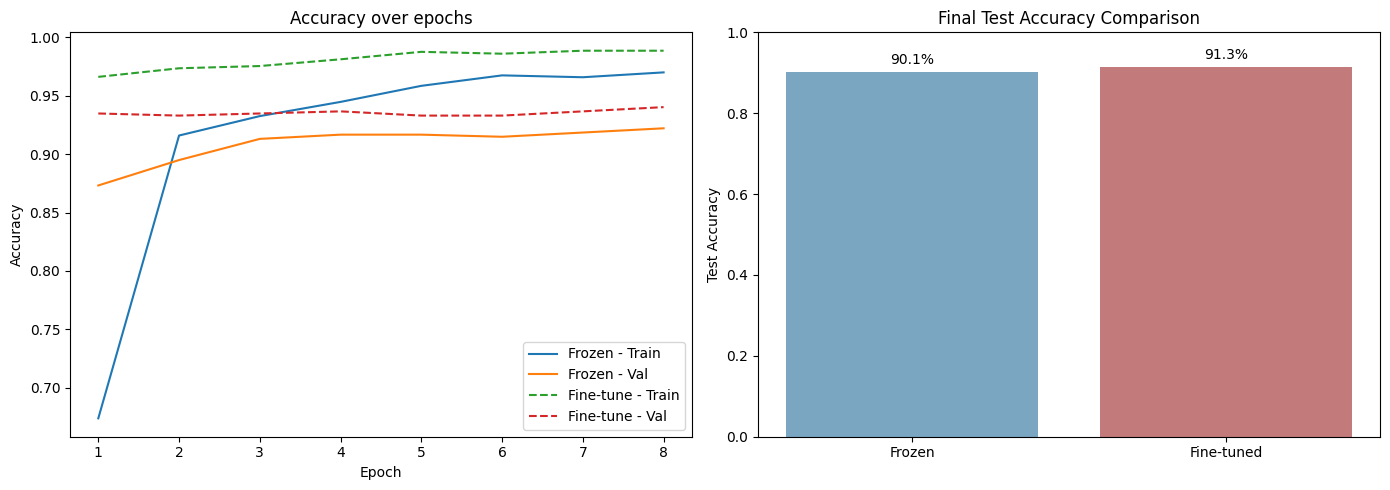

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_frozen = range(1, len(frozen_history["train_acc"]) + 1)
axes[0].plot(epochs_frozen, frozen_history["train_acc"], label="Frozen - Train")
axes[0].plot(epochs_frozen, frozen_history["val_acc"], label="Frozen - Val")
epochs_ft = range(1, len(ft_history["train_acc"]) + 1)
axes[0].plot(epochs_ft, ft_history["train_acc"], label="Fine-tune - Train", linestyle="--")
axes[0].plot(epochs_ft, ft_history["val_acc"], label="Fine-tune - Val", linestyle="--")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].bar(["Frozen", "Fine-tuned"], [frozen_test_acc, fine_tuned_test_acc], color=["#7aa6c2", "#c27a7a"])
axes[1].set_title("Final Test Accuracy Comparison")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1)
for i, v in enumerate([frozen_test_acc, fine_tuned_test_acc]):
    axes[1].text(i, v + 0.02, f"{v*100:.1f}%", ha="center")

plt.tight_layout()
plt.show()


### (Optional) Per-class inspection — confusion on a few sample predictions

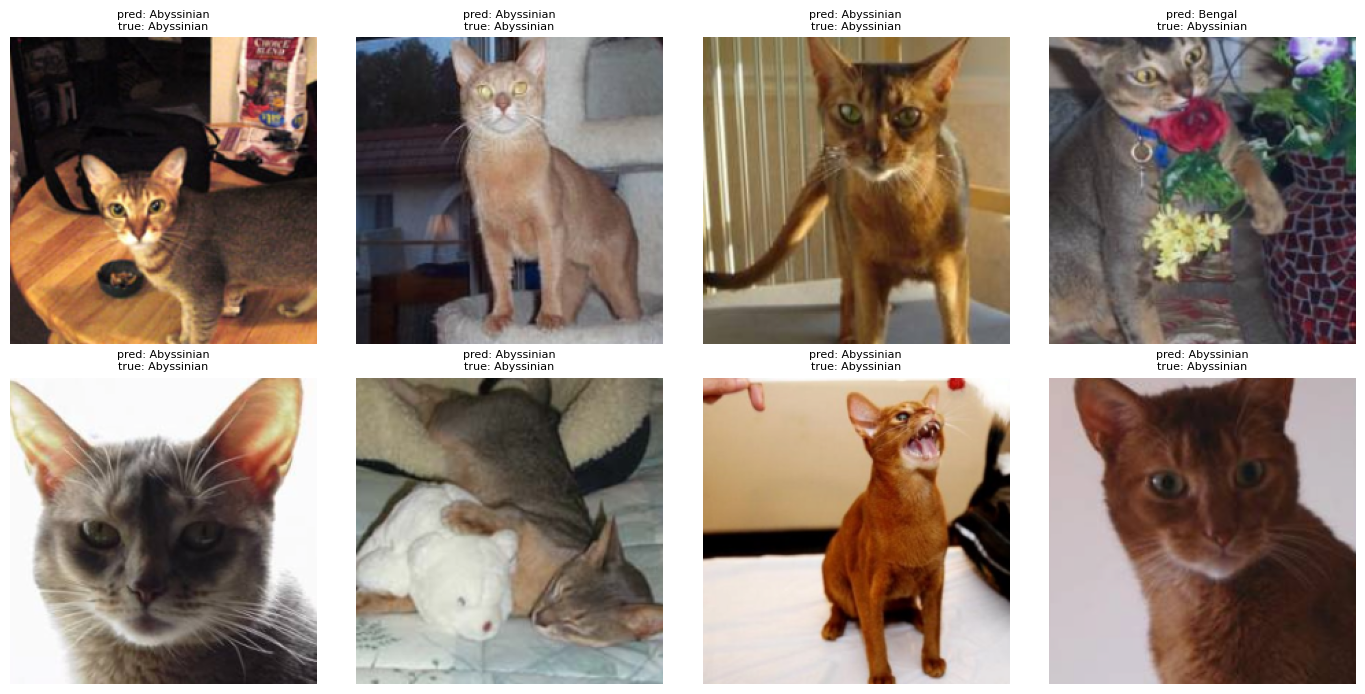

In [ ]:
@torch.no_grad()
def show_predictions(model, dataloader, num_images=8, device=device):
    model.eval()
    model = model.to(device)
    inputs, labels = next(iter(dataloader))
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    fig = plt.figure(figsize=(14, 7))
    for i in range(min(num_images, inputs.size(0))):
        ax = fig.add_subplot(2, 4, i + 1)
        imshow(inputs[i].cpu(), title=f"pred: {CLASS_NAMES[preds[i]]}\ntrue: {CLASS_NAMES[labels[i]]}")
    plt.tight_layout()
    plt.show()

show_predictions(fine_tune_model, test_loader)


## 7. Conclusion

- **Feature Extraction (frozen ResNet50)** trains quickly since only the final layer is updated,
  and gives a solid baseline by reusing ImageNet features as-is.
- **Fine-tuning** (unfreezing `layer3`/`layer4` + a low learning rate) generally improves accuracy
  further, since the network can adapt mid/high-level features specifically to pet breeds
  rather than generic ImageNet categories.
- Data augmentation (random crops, flips, rotation, color jitter) on the training set helps
  reduce overfitting, especially important since the Oxford-IIIT Pet dataset is relatively small
  (~7,300 images across 37 classes).

**Suggested extensions:**
- Try unfreezing the entire network for fine-tuning (with a very small LR) for a further boost.
- Add a learning-rate warm-up or cosine schedule.
- Use `species` labels (cat/dog, binary) in addition to `category` (37-breed) as a secondary task.
- Save the best model with `torch.save(fine_tune_model.state_dict(), "resnet50_pets_finetuned.pth")`.
